# Worksheet 10 — Naive Bayes & Feature Selection (Solved)

**Module:** 5CS037 Concepts and Technologies of AI  
**Topics:** IMDB Sentiment (Naive Bayes) + Feature Selection (RFE)  


## 0. Setup

In [2]:
# Core
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, RocCurveDisplay
)

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources (safe to run multiple times)
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\trija\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 1. Exercise 1 — IMDB Sentiment Analysis with Naive Bayes

### 1.1 Load dataset

In [1]:
import pandas as pd

IMDB_PATH = "IMDB Dataset.csv"
df = pd.read_csv(IMDB_PATH)
df.head()



,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### 1.2 Preprocess reviews (lowercase, remove punctuation, tokenize, stopwords, stemming)

In [ ]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text: str) -> str:
    # a) lowercase
    text = text.lower()
    # b) remove non-alphabetic characters (keep spaces)
    text = re.sub(r"[^a-z\s]", " ", text)
    # c) tokenize + remove stopwords
    tokens = [t for t in text.split() if t not in stop_words]
    # d) stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Apply preprocessing
df["clean_review"] = df["review"].astype(str).apply(preprocess_text)
df[["review", "clean_review", "sentiment"]].head()


### 1.3 Split dataset (80/20)

In [ ]:
X = df["clean_review"].values
y = df["sentiment"].map({"negative": 0, "positive": 1}).values  # 0=negative, 1=positive

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

len(X_train), len(X_test), np.bincount(y_train), np.bincount(y_test)


### 1.4 Bag-of-Words (CountVectorizer) + Train Naive Bayes

In [ ]:
vectorizer = CountVectorizer(max_features=20000)  # you can tune max_features if needed
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)

nb_clf = MultinomialNB()
nb_clf.fit(X_train_bow, y_train)

y_pred = nb_clf.predict(X_test_bow)
y_proba = nb_clf.predict_proba(X_test_bow)[:, 1]


### 1.5 Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC)

In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


Accuracy : 0.8535
Precision: 0.8659
Recall   : 0.8366
F1-score : 0.8510
ROC-AUC  : 0.9191

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.87      0.86      5000
    positive       0.87      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



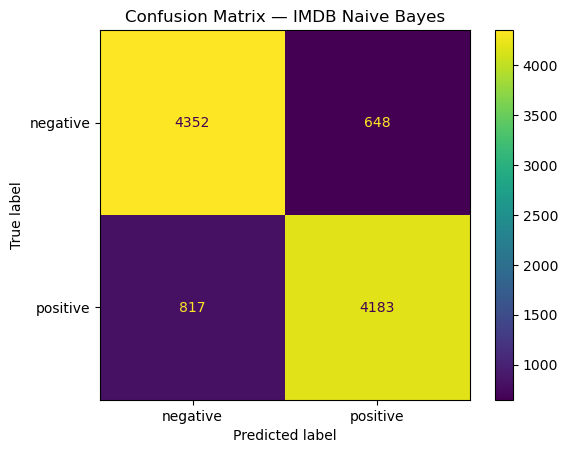

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot()
plt.title("Confusion Matrix — IMDB Naive Bayes")
plt.show()


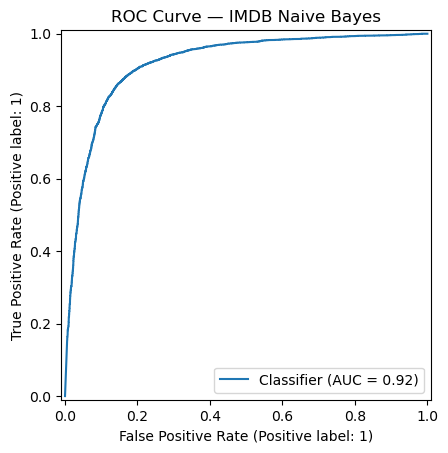

In [16]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — IMDB Naive Bayes")
plt.show()


## 2. Feature Selection Exercise — Wrapper Method (RFE) + Logistic Regression

**Dataset:** Breast Cancer Wisconsin (Prognostic) (WPBC) from UCI.

We attempt to fetch it using `ucimlrepo` (as shown on the UCI page). If fetching fails (e.g., offline environment), the notebook falls back to `sklearn.datasets.load_breast_cancer` so you can still run and submit.


In [17]:
# Models / feature selection
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

def load_wpbc_or_fallback():
    # Try UCI via ucimlrepo
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=16)  # Breast Cancer Wisconsin (Prognostic)
        X = ds.data.features.copy()
        y = ds.data.targets.copy()
        # Convert target to a 1D array (binary), handling common formats
        if isinstance(y, pd.DataFrame):
            # pick first column if multiple
            y_col = y.columns[0]
            y_vec = y[y_col]
        else:
            y_vec = pd.Series(y)
        return X, y_vec, "UCI WPBC (id=16) via ucimlrepo"
    except Exception as e:
        # Fallback: sklearn diagnostic dataset
        from sklearn.datasets import load_breast_cancer
        data = load_breast_cancer(as_frame=True)
        X = data.data
        y_vec = data.target
        return X, pd.Series(y_vec), f"Fallback: sklearn load_breast_cancer (reason: {type(e).__name__})"

X_bc, y_bc, source_note = load_wpbc_or_fallback()
print("Loaded:", source_note)
print("X shape:", X_bc.shape, "| y shape:", y_bc.shape)
X_bc.head()


Loaded: Fallback: sklearn load_breast_cancer (reason: ModuleNotFoundError)
X shape: (569, 30) | y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.1 Basic EDA (summary stats + missing values)

In [18]:
display(X_bc.describe(include="all").T.head(15))


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.37000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.84000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.24000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.10000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.09587,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.09263,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.06154,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.03350,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.17920,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.06154,0.066120,0.09744


In [ ]:
missing_counts = X_bc.isna().sum().sort_values(ascending=False)
missing_counts.head(20)


### 2.2 Train/Test split (80/20)

In [19]:
# Make target numeric if it is categorical (common in WPBC)
y_work = y_bc.copy()
if y_work.dtype == "object":
    # Try common labels like 'N'/'R' or 'nonrecurrence'/'recurrence'
    y_work = y_work.astype(str).str.lower().str.strip()
    # heuristic mapping
    unique = sorted(y_work.unique())
    print("Target unique values:", unique)
    # Map: if contains 'rec' => 1, else 0
    y_work_num = y_work.apply(lambda v: 1 if ("rec" in v or v in ["r", "1", "yes", "true"]) else 0).astype(int)
else:
    y_work_num = pd.to_numeric(y_work, errors="coerce").fillna(0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_work_num, test_size=0.2, random_state=42, stratify=y_work_num
)
X_train.shape, X_test.shape, np.bincount(y_train)


((455, 30), (114, 30), array([170, 285]))

### 2.3 RFE with Logistic Regression (select top 5) + visualize ranking

In [20]:
# Pipeline: impute -> scale -> logistic regression
base_lr = LogisticRegression(max_iter=5000, solver="liblinear")  # liblinear is stable for small/medium data

# We do imputation + scaling before RFE to handle missing values and feature scale
X_train_imp = SimpleImputer(strategy="median").fit_transform(X_train)
X_test_imp  = SimpleImputer(strategy="median").fit(X_train).transform(X_test)  # fit on train only

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

rfe = RFE(estimator=base_lr, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

selected_mask = rfe.support_
ranking = rfe.ranking_

feature_names = np.array(X_bc.columns, dtype=str)
selected_features = feature_names[selected_mask]

print("Top 5 selected features:")
for f in selected_features:
    print("-", f)


Top 5 selected features:
- radius error
- worst radius
- worst texture
- worst area
- worst concave points


In [21]:
# Visualize RFE ranking (1 = best)
rank_df = pd.DataFrame({
    "feature": feature_names,
    "rank": ranking
}).sort_values("rank")

rank_df.head(15)


,feature,rank
10,radius error,1
20,worst radius,1
23,worst area,1
21,worst texture,1
27,worst concave points,1
22,worst perimeter,2
13,area error,3
24,worst smoothness,4
3,mean area,5
26,worst concavity,6


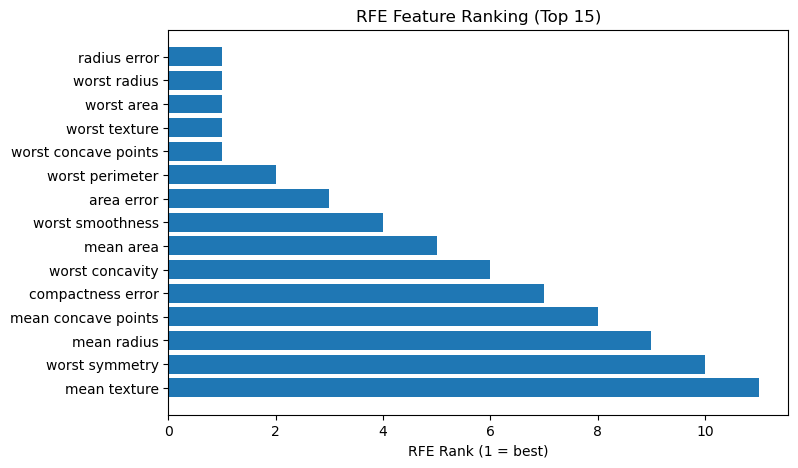

In [22]:
# Plot ranking for top 15 (lower rank is better)
topk = 15
plot_df = rank_df.head(topk).iloc[::-1]  # reverse for nicer horizontal plot

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["rank"])
plt.xlabel("RFE Rank (1 = best)")
plt.title("RFE Feature Ranking (Top 15)")
plt.show()


### 2.4 Train Logistic Regression on (a) all features vs (b) selected features

In [23]:
def eval_lr(Xtr, Xte, ytr, yte, label="model"):
    lr = LogisticRegression(max_iter=5000, solver="liblinear")
    lr.fit(Xtr, ytr)
    pred = lr.predict(Xte)
    proba = lr.predict_proba(Xte)[:, 1] if hasattr(lr, "predict_proba") else None

    acc = accuracy_score(yte, pred)
    prec = precision_score(yte, pred, zero_division=0)
    rec = recall_score(yte, pred, zero_division=0)
    f1 = f1_score(yte, pred, zero_division=0)
    auc = roc_auc_score(yte, proba) if proba is not None else np.nan
    return {
        "Model": label,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    }, pred, proba

# (a) all features
res_all, pred_all, proba_all = eval_lr(X_train_scaled, X_test_scaled, y_train, y_test, "LogReg (All features)")

# (b) selected features only
X_train_sel = X_train_scaled[:, selected_mask]
X_test_sel  = X_test_scaled[:, selected_mask]
res_sel, pred_sel, proba_sel = eval_lr(X_train_sel, X_test_sel, y_train, y_test, "LogReg (Top 5 via RFE)")

results = pd.DataFrame([res_all, res_sel])
results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LogReg (All features),0.982456,0.986111,0.986111,0.986111,0.995701
1,LogReg (Top 5 via RFE),0.947368,0.958333,0.958333,0.958333,0.994709


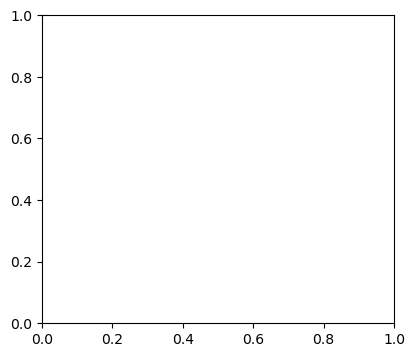

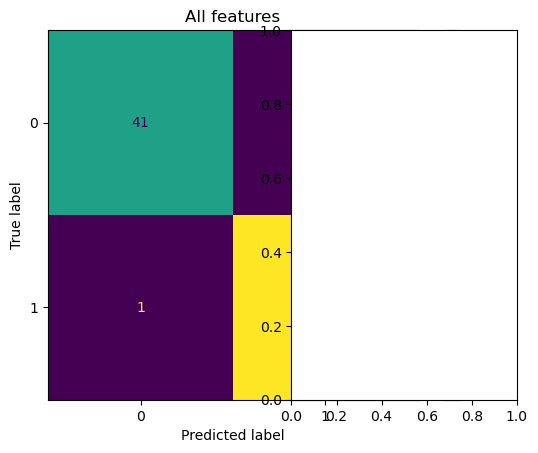

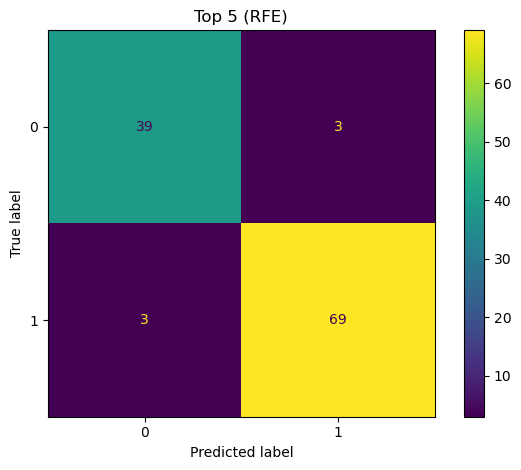

In [24]:
# Confusion matrices
fig = plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
ConfusionMatrixDisplay.from_predictions(y_test, pred_all)
plt.title("All features")

plt.subplot(1,2,2)
ConfusionMatrixDisplay.from_predictions(y_test, pred_sel)
plt.title("Top 5 (RFE)")

plt.tight_layout()
plt.show()


### 2.5 Experiment: top 3 and top 7 features

In [25]:
def rfe_select_and_eval(k):
    rfe_k = RFE(estimator=base_lr, n_features_to_select=k)
    rfe_k.fit(X_train_scaled, y_train)
    mask_k = rfe_k.support_
    Xtr_k = X_train_scaled[:, mask_k]
    Xte_k = X_test_scaled[:, mask_k]
    res, _, _ = eval_lr(Xtr_k, Xte_k, y_train, y_test, f"LogReg (Top {k} via RFE)")
    feats = feature_names[mask_k]
    return res, feats

res3, feats3 = rfe_select_and_eval(3)
res7, feats7 = rfe_select_and_eval(7)

exp_results = pd.DataFrame([res_all, res3, res_sel, res7]).reset_index(drop=True)
exp_results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LogReg (All features),0.982456,0.986111,0.986111,0.986111,0.995701
1,LogReg (Top 3 via RFE),0.938596,0.971014,0.930556,0.950355,0.989749
2,LogReg (Top 5 via RFE),0.947368,0.958333,0.958333,0.958333,0.994709
3,LogReg (Top 7 via RFE),0.947368,0.958333,0.958333,0.958333,0.994709


In [26]:
print("Top 3 features:", list(feats3))
print("Top 5 features:", list(selected_features))
print("Top 7 features:", list(feats7))


Top 3 features: [np.str_('worst radius'), np.str_('worst area'), np.str_('worst concave points')]
Top 5 features: [np.str_('radius error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst area'), np.str_('worst concave points')]
Top 7 features: [np.str_('radius error'), np.str_('area error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concave points')]


### 2.6 Discussion

- **If performance improves** with fewer features: RFE removed noisy/irrelevant features, making the model simpler and generalize better.  
- **If performance drops** with fewer features: important information may have been removed; the model needs more features to capture patterns.  
- In general, feature selection can **reduce overfitting**, **speed up training**, and **make the model more interpretable**, but selecting too few features can hurt accuracy.
